In [1]:
import numpy as np
import pandas as pd
import bt as bt
import yfinance as yf
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.pyplot as plt
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
from io import StringIO

In [2]:
# Verificar o tipo da coluna antes de aplicar replace

driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()))

url = 'https://www.fundamentus.com.br/resultado.php'

driver.get(url)
local_tabela = '/html/body/div[1]/div[2]/table'
elemento = driver.find_element("xpath", local_tabela)
html_tabela = elemento.get_attribute('outerHTML')
tabela = pd.read_html(StringIO(html_tabela), thousands = ".")[0]

tabela = tabela.set_index("Papel")


# Função para garantir que substituímos apenas nas colunas de string
def clean_column(col):
    # Verifica se a coluna é do tipo 'object' (strings)
    if col.dtype == 'object':
        # Substitui os valores "%" e ","
        col = col.str.replace("%", "", regex=False)
        col = col.str.replace(".", "", regex=False)
        col = col.str.replace(",", ".", regex=False)
        # Após as substituições, converte para tipo numérico (float), forçando erros para NaN
        col = pd.to_numeric(col, errors='coerce')
    return col

# Aplicando a limpeza nas colunas de strings
for col in tabela.columns:
    tabela[col] = clean_column(tabela[col])

# Filtrando e ordenando os dados
tabela = tabela[['Cotação', 'Mrg. Líq.', 'EV/EBIT', 'ROIC', 'ROE', 'P/L', 'Liq.2meses']]
tabela = tabela[tabela['Liq.2meses'] > 1000000]
tabela = tabela[tabela['EV/EBIT'] > 0]
tabela = tabela[tabela['Mrg. Líq.'] > 25]
tabela = tabela[tabela['ROE'] > 5]
tabela = tabela[tabela['P/L'] < 30]
tabela = tabela[tabela['ROIC'] > 8]

# Rankeando os ativos com base nos melhores EVEBIT e ROIC
tabela['ranking_ev_ebit'] = tabela['EV/EBIT'].rank(ascending=True)
tabela['ranking_PL'] = tabela['P/L'].rank(ascending=True)
tabela['ranking_ML'] = tabela['Mrg. Líq.'].rank(ascending=False)

tabela['ranking_roic'] = tabela['ROIC'].rank(ascending=False)
tabela['ranking_roe'] = tabela['ROE'].rank(ascending=False)
tabela['ranking_total'] = tabela['ranking_ev_ebit'] + tabela['ranking_roic'] + tabela['ranking_roe'] + tabela['ranking_PL'] + tabela['ranking_ML']
tabela = tabela.sort_values('ranking_total')

driver.quit()

In [3]:
start = "2010-1-1"
end = "2024-11-1"
tabela = tabela.head(8)
tickers = tabela.index
tickers = [acao + '.SA' for acao in tickers]
wallet = yf.download(tickers, start, end)["Adj Close"]
wallet = wallet.dropna()

wallet

Failed to get ticker 'MULT3.SA' reason: Expecting value: line 1 column 1 (char 0)
[**********************50%                       ]  4 of 8 completedFailed to get ticker 'VIVA3.SA' reason: Expecting value: line 1 column 1 (char 0)
Failed to get ticker 'ISAE4.SA' reason: Expecting value: line 1 column 1 (char 0)
[*********************100%***********************]  8 of 8 completed

8 Failed downloads:
['MULT3.SA', 'VIVA3.SA', 'ISAE4.SA']: YFTzMissingError('$%ticker%: possibly delisted; no timezone found')
['SYNE3.SA', 'B3SA3.SA', 'PRIO3.SA', 'LAVV3.SA', 'SBSP3.SA']: JSONDecodeError('Expecting value: line 1 column 1 (char 0)')


Ticker,B3SA3.SA,ISAE4.SA,LAVV3.SA,MULT3.SA,PRIO3.SA,SBSP3.SA,SYNE3.SA,VIVA3.SA
Date,,,,,,,,


In [4]:
carteira_25 = ["AGRO3", "CSAN3", "UNIP6", "BRKM5", "CMIG4", "BBAS3", "KLBN11", "VALE3"]
carteira = carteira_25
carteira = [acao + ".SA" for acao in carteira]

In [5]:
# Obter os preços históricos
data = bt.get(tickers, start='2023-01-01', end='2024-11-01')

data

[*********************100%***********************]  1 of 1 completed

1 Failed download:
['SYNE3.SA']: JSONDecodeError('Expecting value: line 1 column 1 (char 0)')
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['PRIO3.SA']: JSONDecodeError('Expecting value: line 1 column 1 (char 0)')
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['SBSP3.SA']: JSONDecodeError('Expecting value: line 1 column 1 (char 0)')
Failed to get ticker 'ISAE4.SA' reason: Expecting value: line 1 column 1 (char 0)
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['ISAE4.SA']: YFTzMissingError('$%ticker%: possibly delisted; no timezone found')
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['LAVV3.SA']: JSONDecodeError('Expecting value: line 1 column 1 (char 0)')
Failed to get ticker 'VIVA3.SA' reason: Expecting value: line 1 column 1 (char 0)
[********

,syne3sa,prio3sa,sbsp3sa,isae4sa,lavv3sa,viva3sa,b3sa3sa,mult3sa
Date,,,,,,,,


In [6]:
# Passo 1: Calcular os pesos otimizados
precos = data.copy()
retornos = precos.pct_change().apply(lambda x: np.log(1 + x)).dropna()
media_retornos = retornos.mean()
matriz_cov = retornos.cov()

# Configurações
numero_carteiras = 10000
tabela_retornos_esperados = np.zeros(numero_carteiras)
tabela_volatilidades_esperadas = np.zeros(numero_carteiras)
tabela_sharpe = np.zeros(numero_carteiras)
tabela_pesos = np.zeros((numero_carteiras, len(precos.columns)))

# Simulação de carteiras
for k in range(numero_carteiras):
    pesos = np.random.random(len(precos.columns))
    pesos = pesos / np.sum(pesos)
    tabela_pesos[k, :] = pesos
    
    tabela_retornos_esperados[k] = np.sum(media_retornos * pesos * 252)
    tabela_volatilidades_esperadas[k] = np.sqrt(np.dot(pesos.T, np.dot(matriz_cov * 252, pesos)))
    tabela_sharpe[k] = tabela_retornos_esperados[k] / tabela_volatilidades_esperadas[k]

# Carteira com Sharpe máximo
indice_do_sharpe_maximo = tabela_sharpe.argmax()
pesos_otimizados = tabela_pesos[indice_do_sharpe_maximo]

pesos_otimizados

C:\Users\Emanuel Venditto\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\lib\_function_base_impl.py:562: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
C:\Users\Emanuel Venditto\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\_core\_methods.py:139: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
C:\Users\Emanuel Venditto\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\pandas\core\frame.py:11211: RuntimeWarning: Degrees of freedom <= 0 for slice
  base_cov = np.cov(mat.T, ddof=ddof)
C:\Users\Emanuel Venditto\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\lib\_function_base_impl.py:2848: RuntimeWarning: divide by zer

array([0.03546137, 0.14749491, 0.10801842, 0.11953911, 0.14622043,
       0.14976198, 0.14140457, 0.15209921])

In [7]:
# Converter para dicionário (formato necessário para WeighSpecified)
ativos = precos.columns
pesos_dicionario = dict(zip(ativos, pesos_otimizados))
print("Pesos otimizados:", pesos_dicionario)

Pesos otimizados: {'syne3sa': np.float64(0.03546136640792885), 'prio3sa': np.float64(0.14749490955848468), 'sbsp3sa': np.float64(0.10801841989640582), 'isae4sa': np.float64(0.1195391111011923), 'lavv3sa': np.float64(0.14622043450931002), 'viva3sa': np.float64(0.14976197541312683), 'b3sa3sa': np.float64(0.14140457373775447), 'mult3sa': np.float64(0.15209920937579696)}


In [8]:
# Passo 2: Usar os pesos na estratégia BT
strategy1 = bt.Strategy('Optimized Portfolio',
                       [bt.algos.RunMonthly(),
                        bt.algos.SelectAll(),
                        bt.algos.WeighSpecified(**pesos_dicionario),
                        bt.algos.Rebalance()])
# Estratégia com pesos ajustados pelo risco (WeighRiskAdjusted)
# Aqui você pode definir a estratégia ajustada pelo risco com base em sua preferência.
# Por exemplo, uma forma de ajustar os pesos pode ser através da inversão da volatilidade.
# Isso significa que ativos mais voláteis terão pesos menores.

# Calcular a volatilidade dos ativos
volatilidades = np.sqrt(np.diag(matriz_cov))  # Volatilidade individual dos ativos (desvio padrão)
volatilidades_invertidas = 1 / volatilidades  # Inversão da volatilidade para o ajuste de risco

# Normalizar os pesos ajustados pelo risco
pesos_ajustados = volatilidades_invertidas / np.sum(volatilidades_invertidas)
pesos_ajustados_dicionario = dict(zip(tickers, pesos_ajustados))


# Estratégia com pesos ajustados pelo risco (WeighRiskAdjusted)
strategy2 = bt.Strategy('Risk Adjusted Portfolio',
                                     [bt.algos.RunMonthly(),
                                      bt.algos.SelectAll(),
                                      bt.algos.WeighSpecified(**pesos_ajustados_dicionario),
                                      bt.algos.Rebalance()])

In [9]:
# Passo 3: Criar e rodar os backtests
backtest_optimized = bt.Backtest(strategy1, data)
backtest_risk_adjusted = bt.Backtest(strategy2, data)

# Rodar os backtests para as três estratégias
result = bt.run(backtest_optimized, backtest_risk_adjusted)

IndexError: index 0 is out of bounds for axis 0 with size 0

Stat                 Optimized Portfolio    Risk Adjusted Portfolio
-------------------  ---------------------  -------------------------
Start                2014-01-22             2014-01-22
End                  2024-10-31             2024-10-31
Risk-free rate       0.00%                  0.00%

Total Return         1289.34%               666.78%
Daily Sharpe         1.21                   0.97
Daily Sortino        2.01                   1.56
CAGR                 27.67%                 20.81%
Max Drawdown         -46.13%                -47.02%
Calmar Ratio         0.60                   0.44

MTD                  -2.07%                 -3.51%
3m                   -4.64%                 -1.85%
6m                   -1.63%                 -1.68%
YTD                  -9.07%                 -7.31%
1Y                   -1.34%                 4.78%
3Y (ann.)            10.37%                 7.99%
5Y (ann.)            22.44%                 16.65%
10Y (ann.)           29.93%                

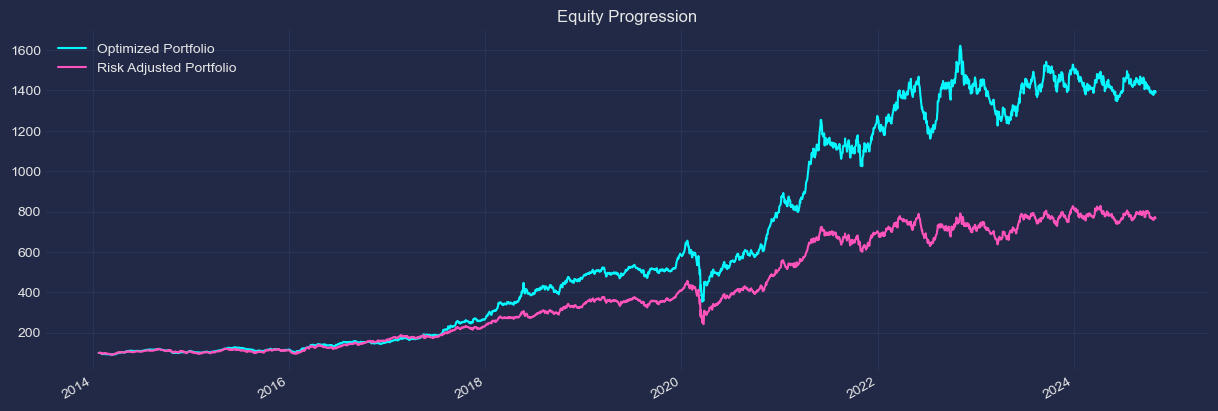

In [ ]:
# Exibir os resultados comparativos
result.plot()
result.display()